In [1]:
!pip install econml==0.16.0 scikit-learn==1.2.2 numpy==1.26.4 pandas==2.1.4 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 42.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 13.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pa

In [2]:
!pip install causalml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 16.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
econml 0.16.0 requires 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import statsmodels.api as sm
import patsy
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from econml.dr import DRLearner
from tqdm import trange
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  object 
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  object 
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  object 
 8   segment          64000 non-null  object 
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), object(4)
memory usage: 5.9+ MB


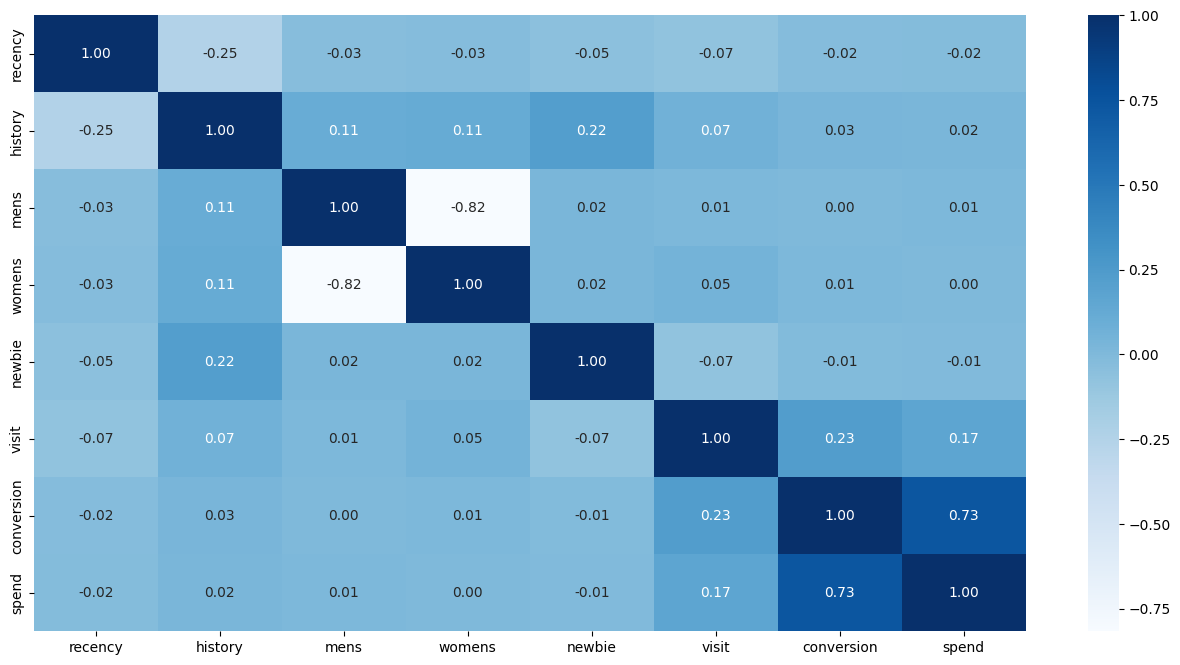

In [3]:
df.shape
df.head()
df.describe(include='all')
df.info()
x_values = df.select_dtypes(include=['number'])
corr_matrix = x_values.corr()

plt.figure(figsize=(16, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.show()

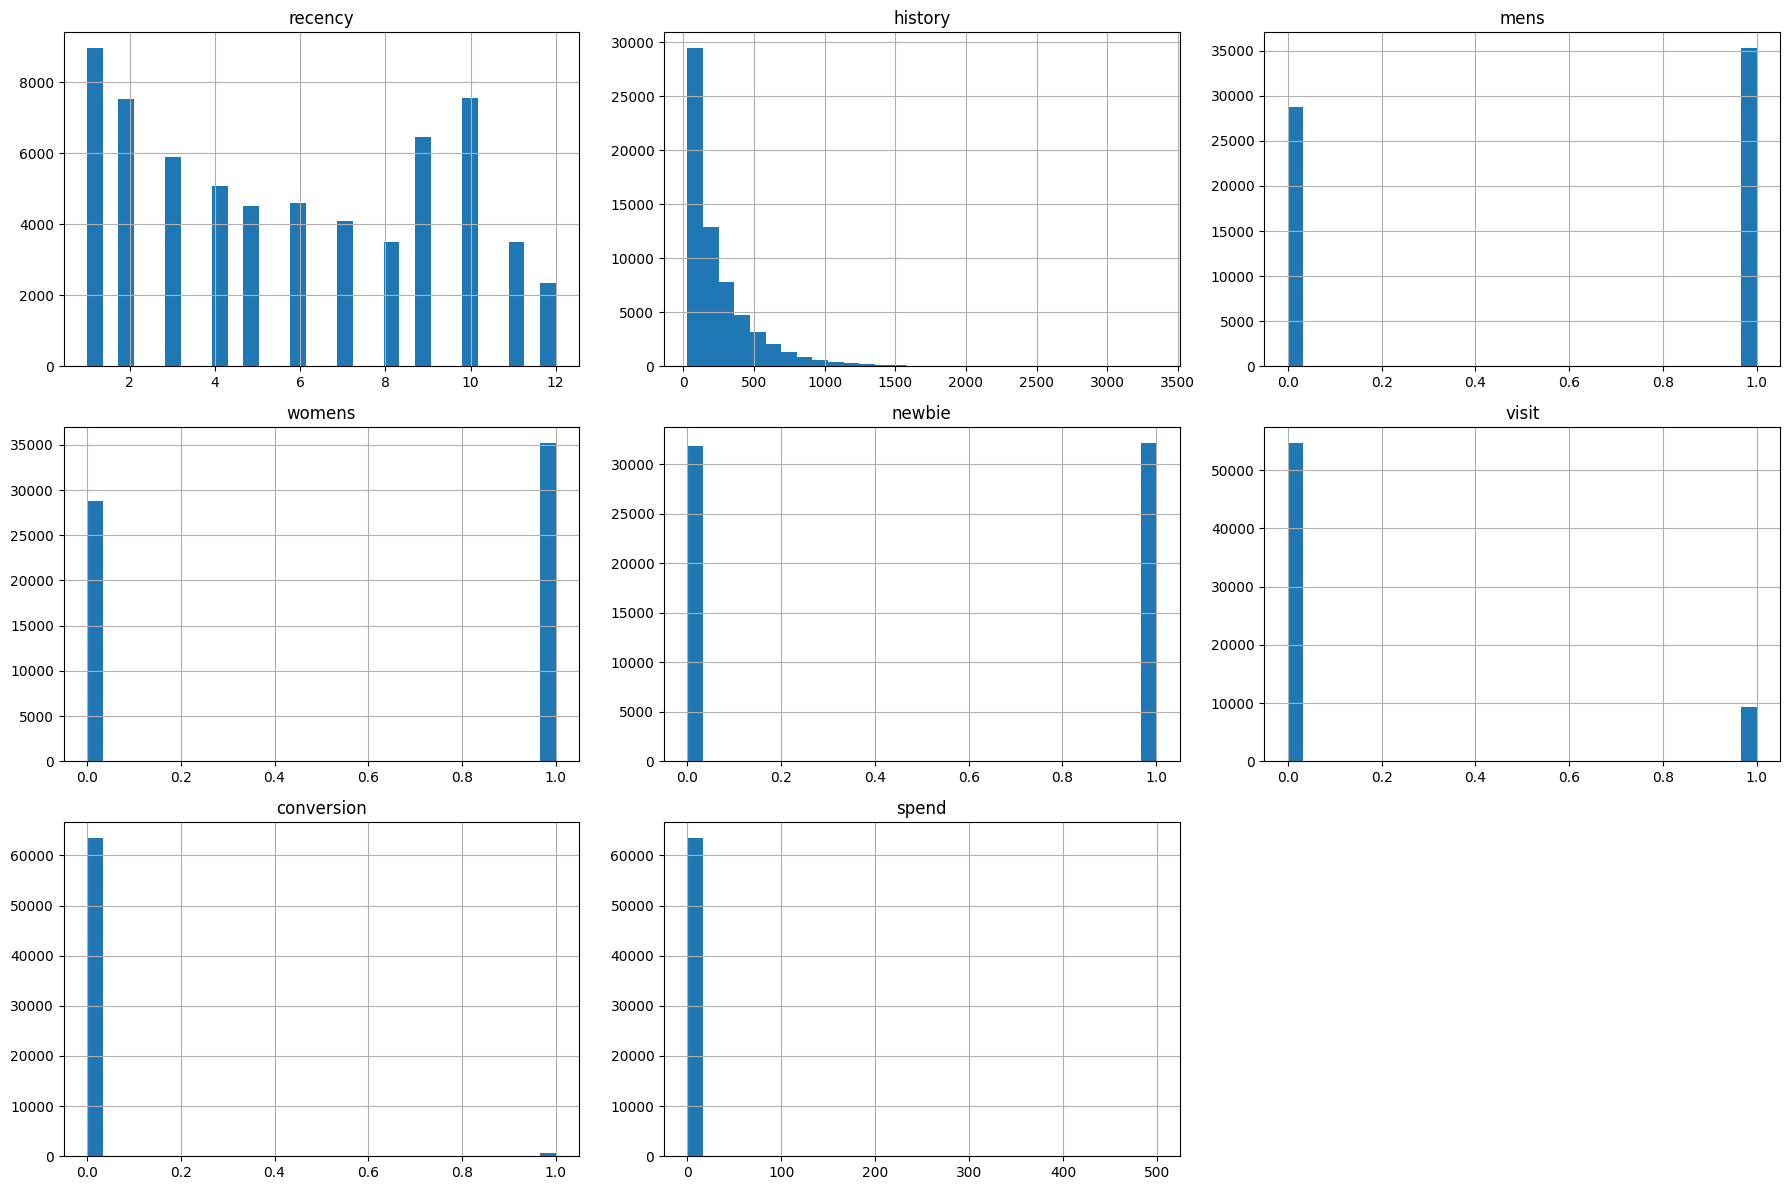

In [19]:
# Plot histograms for all numeric columns
x_values.hist(figsize=(18, 12), bins=30)
plt.tight_layout()
plt.show()

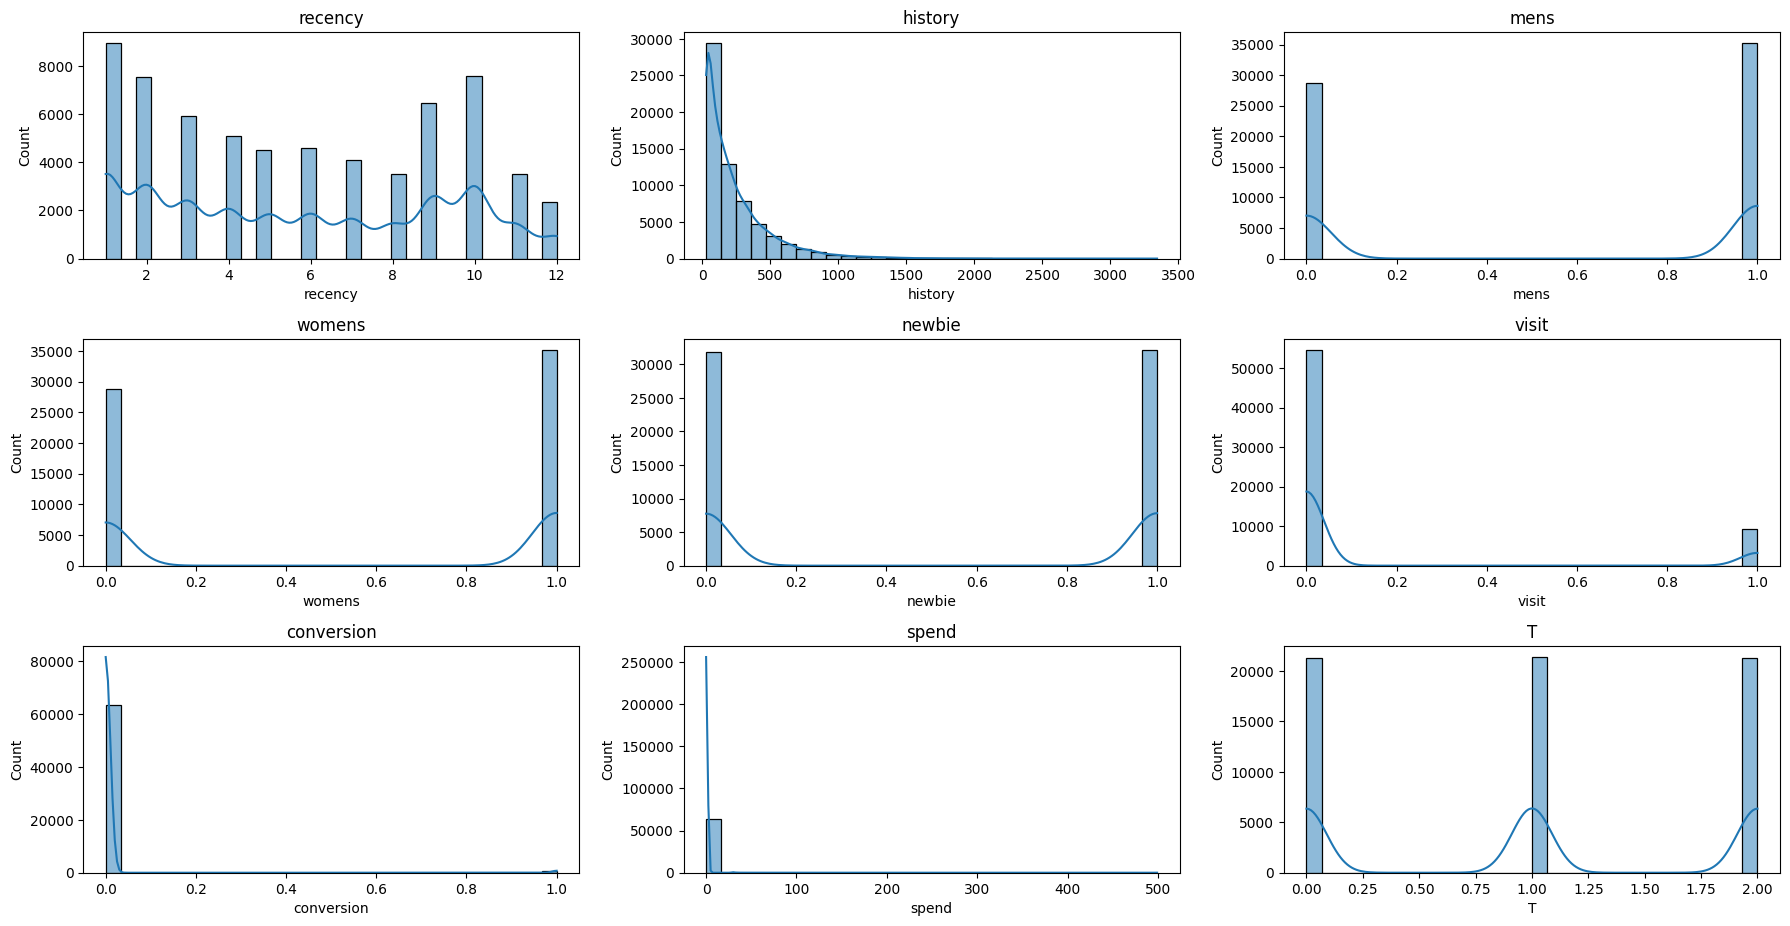

In [20]:
numeric_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(18, 12))

for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols) // 3 + 1, 3, i + 1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

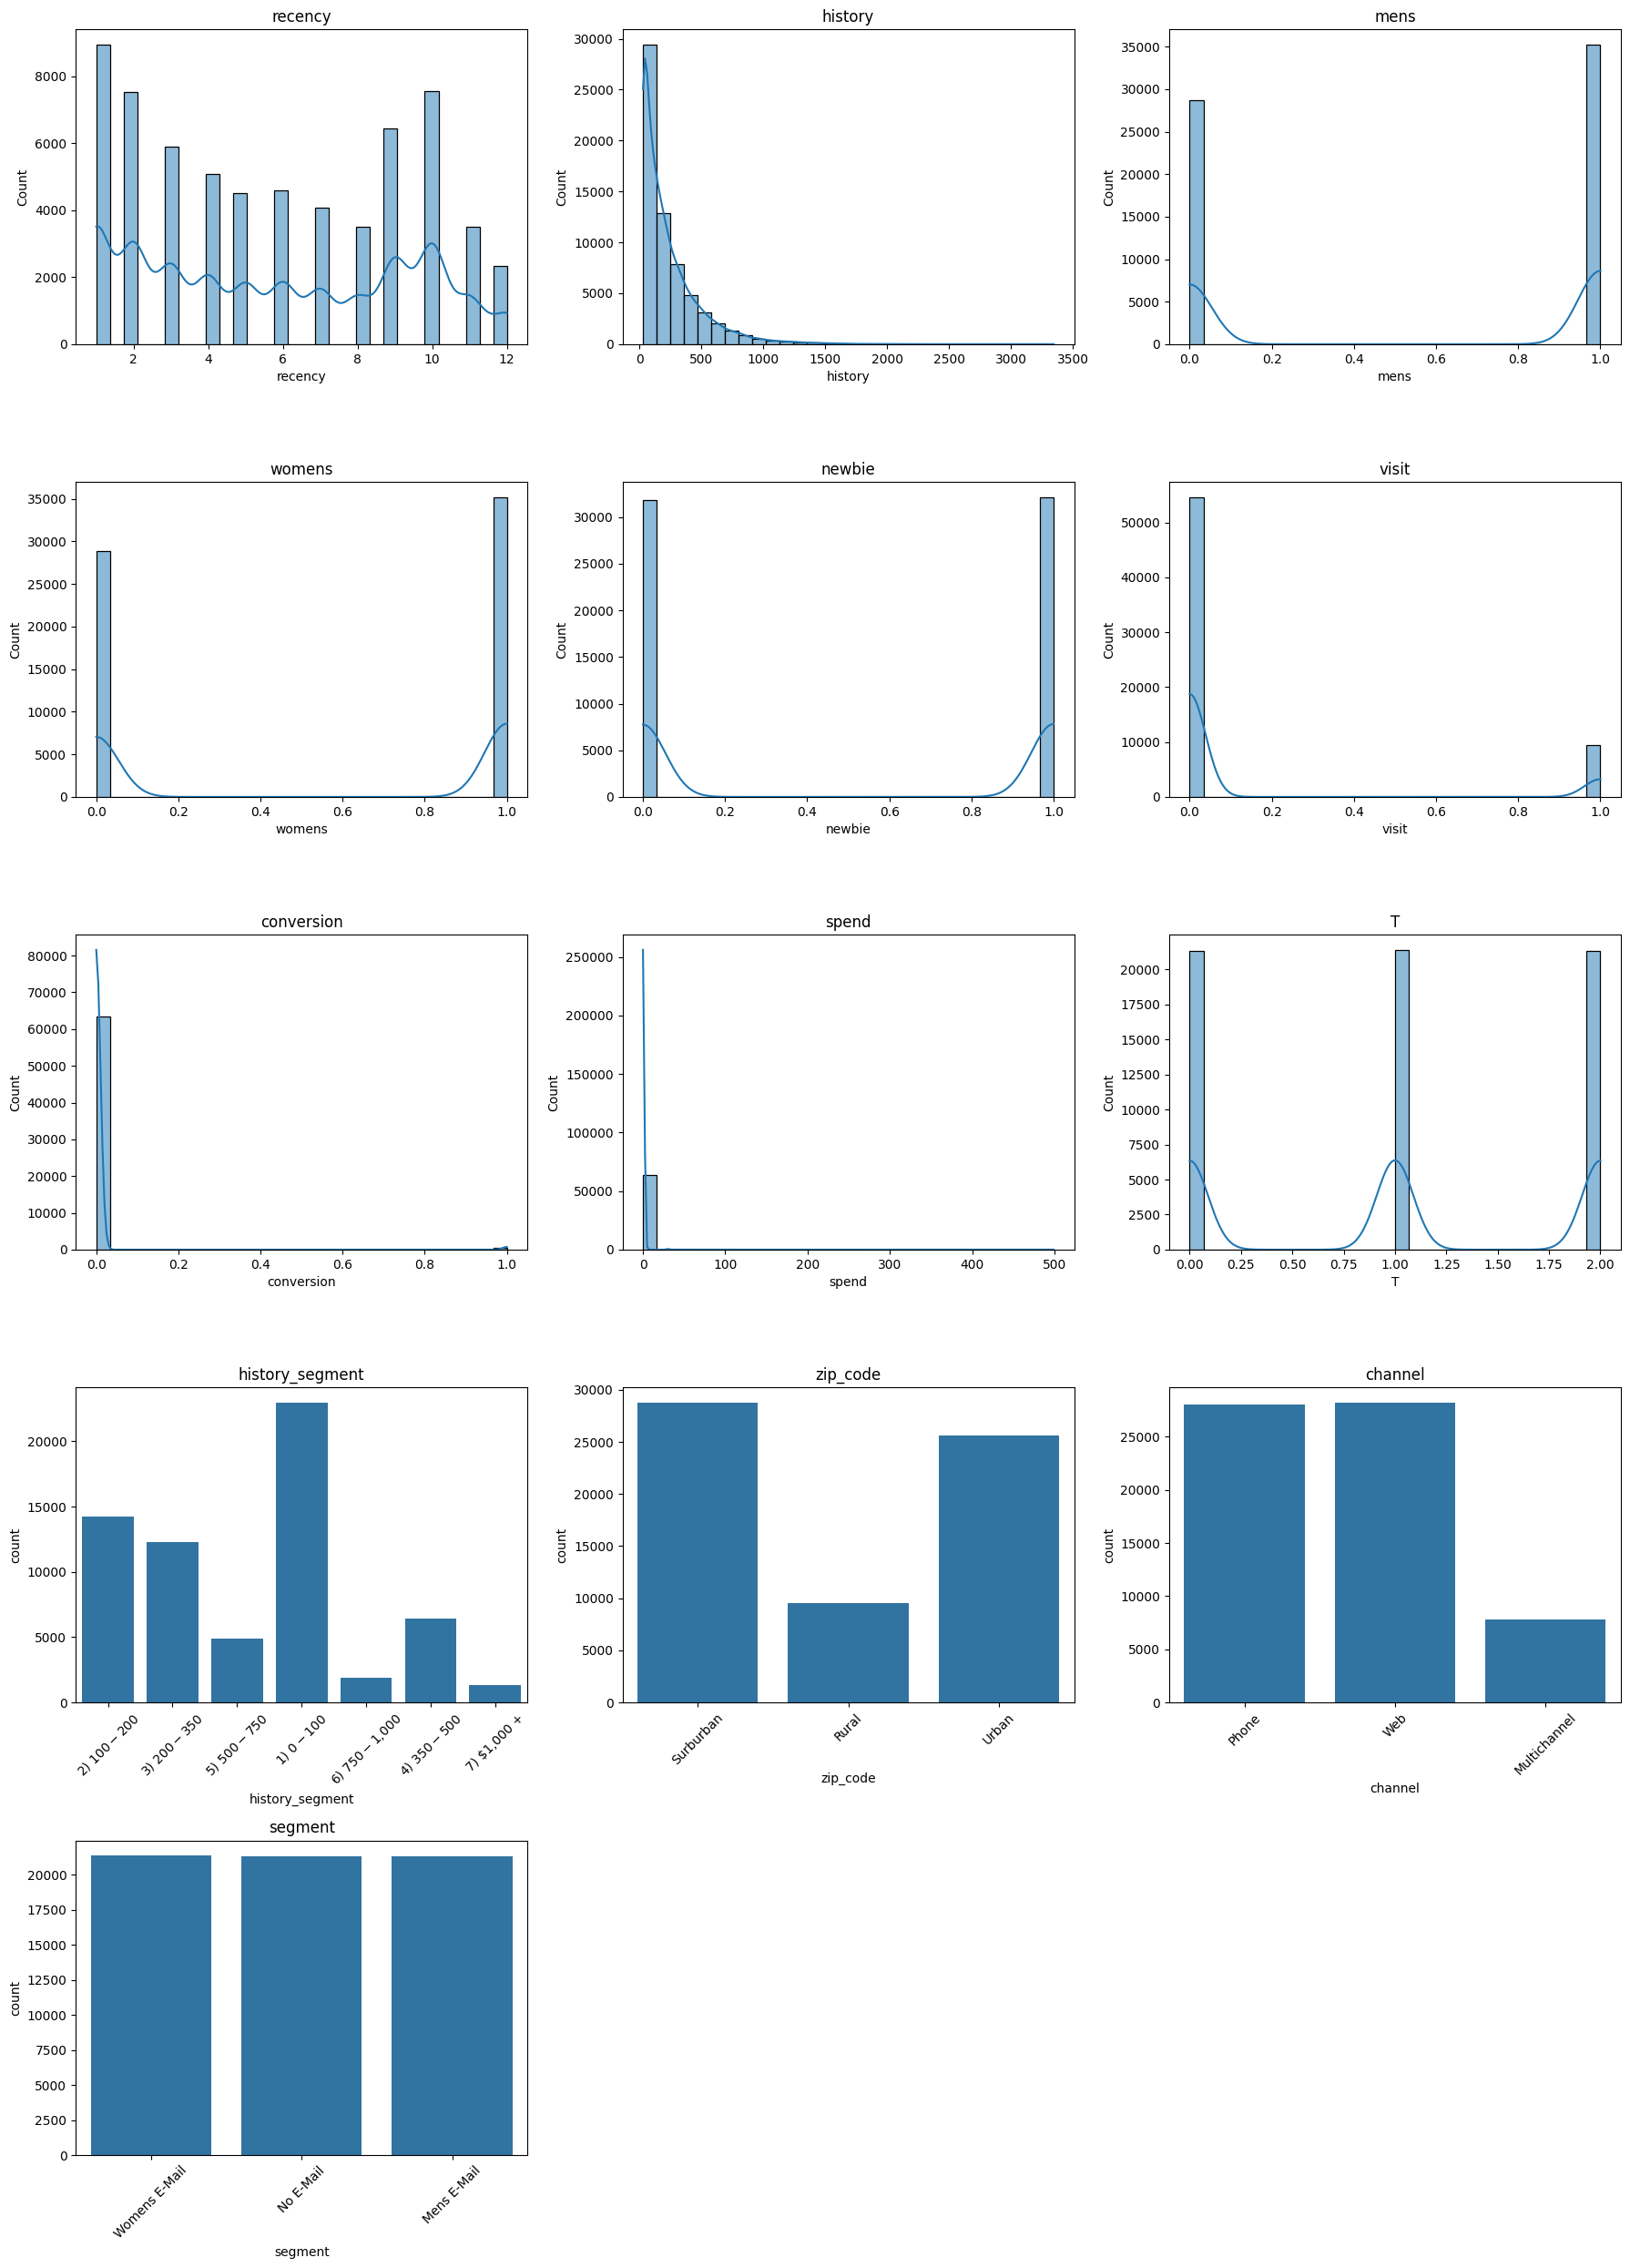

In [22]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Combine them
all_cols = list(numeric_cols) + list(categorical_cols)

plt.figure(figsize=(18, 5 * ((len(all_cols) // 3) + 1)))

for i, col in enumerate(all_cols):
    plt.subplot(len(all_cols) // 3 + 1, 3, i + 1)

    if col in numeric_cols:
        sns.histplot(df[col], bins=30, kde=True)
    else:
        sns.countplot(x=df[col])
        plt.xticks(rotation=45)

    plt.title(col)

plt.tight_layout()
plt.show()

In [4]:
df['T'] = df['segment'].map({
    'No E-Mail': 0,
    'Womens E-Mail': 1,
    'Mens E-Mail': 2
})

covariates = [
    'recency','history','history_segment',
    'mens','womens',
    'zip_code','newbie','channel'
]


T = df['T'].to_numpy()
Y = df['conversion'].to_numpy()
X = pd.get_dummies(
    df[covariates],
    columns=['zip_code','channel','history_segment'],
    drop_first=True
).values


n = len(df)

In [5]:
cols = ['recency','history','mens','womens','newbie']
result = {
    col: df.groupby('T')[col].mean()
    for col in cols
}

df_means = pd.DataFrame(result)
print(df_means)

# Checking covariate balance across treatment groups.
# For each covariate, we compute its mean within each treatment level (T).
#
# If the experiment is properly randomized, the covariates should have
# very similar means across groups — meaning no systematic differences
# between treated and control units.
#
# In this case, the covariate means are essentially identical across T,
# indicating statistically perfect balance. This is consistent with a
# well-executed randomization process.

    recency     history      mens    womens    newbie
T                                                    
0  5.749695  240.882653  0.553224  0.547639  0.501971
1  5.767850  242.536633  0.548932  0.550101  0.503250
2  5.773642  242.835931  0.550946  0.551415  0.501525


In [6]:
formula = "T ~ recency + history + mens + womens + newbie"
y, X_df = patsy.dmatrices(formula, df, return_type='dataframe')

model_T = sm.MNLogit(y, X_df).fit()
print(model_T.summary())

Optimization terminated successfully.
         Current function value: 1.098579
         Iterations 3
                          MNLogit Regression Results                          
Dep. Variable:                      T   No. Observations:                64000
Model:                        MNLogit   Df Residuals:                    63988
Method:                           MLE   Df Model:                           10
Date:                Sun, 01 Mar 2026   Pseudo R-squ.:               2.874e-05
Time:                        08:29:28   Log-Likelihood:                -70309.
converged:                       True   LL-Null:                       -70311.
Covariance Type:            nonrobust   LLR p-value:                    0.9455
       T=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0163      0.042      0.383      0.701      -0.067       0.099
recency        0.0020      0.

In [7]:
formula = "Y ~ recency + history + mens + womens + newbie"
y2, X2 = patsy.dmatrices(formula, df, return_type='dataframe')

model_Y = sm.Logit(y2, X2).fit()
print(model_Y.summary())

Optimization terminated successfully.
         Current function value: 0.050684
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                64000
Model:                          Logit   Df Residuals:                    63994
Method:                           MLE   Df Model:                            5
Date:                Sun, 01 Mar 2026   Pseudo R-squ.:                 0.01586
Time:                        08:29:40   Log-Likelihood:                -3243.8
converged:                       True   LL-Null:                       -3296.1
Covariance Type:            nonrobust   LLR p-value:                 5.829e-21
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.8805      0.157    -30.993      0.000      -5.189      -4.572
recency       -0.0592      0.

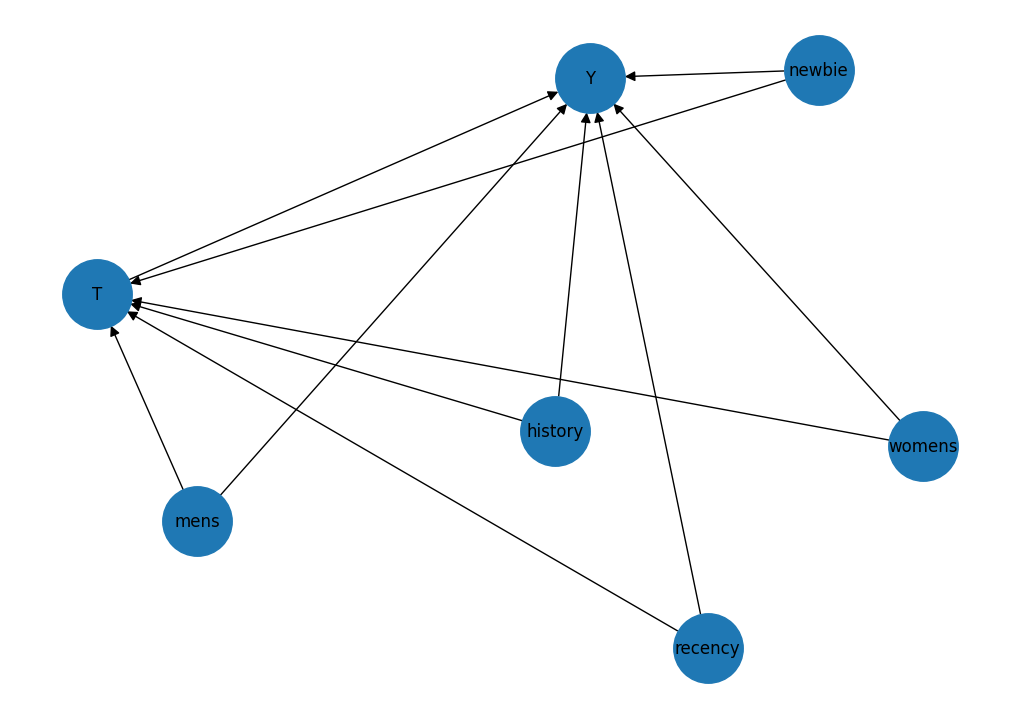

In [8]:
G = nx.DiGraph()
edges = [
    ("recency", "T"),
    ("recency", "Y"),
    ("history", "T"),
    ("history", "Y"),
    ("mens", "T"),
    ("mens", "Y"),
    ("womens", "T"),
    ("womens", "Y"),
    ("newbie", "T"),
    ("newbie", "Y"),
    ("T", "Y")
]

G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=15)
plt.figure(figsize=(10, 7))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=2500,
    font_size=12,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=15
)
plt.show()

In [9]:
# Double Machine Learning (DML)

model_propensity = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    random_state=42
)

model_regression = RandomForestRegressor(
    n_estimators=400,
    max_depth=8,
    random_state=42
)

dr = DRLearner(
    model_propensity=model_propensity,
    model_regression=model_regression,
    random_state=42
)


dr.fit(Y,T, X = X )

# Implementation of Double Machine Learning using the DRLearner.
# The algorithm fits two auxiliary (nuisance) models:
#   (1) propensity score     -> model_propensity
#   (2) outcome model        -> model_regression
#
# The DRLearner combines these components through the Doubly Robust
# approach, which reduces bias and enables valid inference even when
# one of the nuisance models is misspecified.
#
# The internal cross-fitting procedure characterizes the Double Machine
# Learning framework described by Chernozhukov et al. (2018).

In [10]:
effects_by_t = dr.effect(X, T0=0, T1=1)
print("Womens vs No Email:", effects_by_t.mean())
effects_by_t = dr.effect(X, T0=0, T1=2)
print("Mens vs No Email:", effects_by_t.mean())

# Here we compute the average effect for each comparison of interest:
#   - Womens E-Mail vs No E-Mail  (T1=1, T0=0)
#   - Mens E-Mail   vs No E-Mail  (T1=2, T0=0)
#
# dr.effect(X, T0, T1) returns the individual treatment effects (CATE)
# for each observation, and we use .mean() to obtain the average causal
# effect for that comparison.
#
# This allows us to interpret the causal impact of each email type.

Womens vs No Email: 0.0032445755243435356
Mens vs No Email: 0.006799876534745651


In [11]:
cate_womens = dr.effect(X, T0=0, T1=1)
cate_mens   = dr.effect(X, T0=0, T1=2)

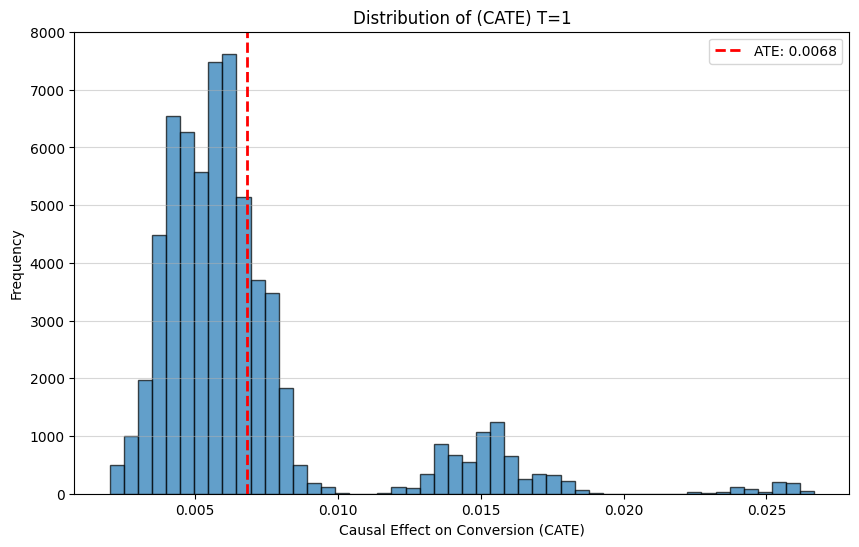

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(cate_mens, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(cate_mens.mean(), color='red', linestyle='dashed', linewidth=2,
            label=f'ATE: {cate_mens.mean():.4f}')
plt.title('Distribution of (CATE) T=1')
plt.xlabel('Causal Effect on Conversion (CATE)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

# The vertical dashed line marks the Average Treatment Effect (ATE), providing a reference
# point to compare the overall effect against the distribution of individual effects.
#
# This plot helps us understand not only the magnitude of the causal effect,
# but also how much it varies between users.

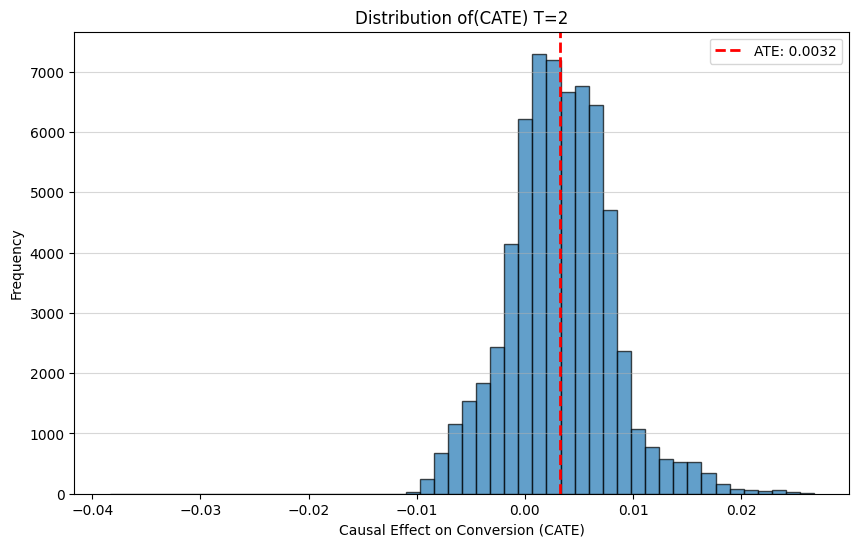

In [24]:
plt.figure(figsize=(10, 6))
plt.hist(cate_womens, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(cate_womens.mean(), color='red', linestyle='dashed', linewidth=2,
            label=f'ATE: {cate_womens.mean():.4f}')
plt.title('Distribution of(CATE) T=2')
plt.xlabel('Causal Effect on Conversion (CATE)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

# The vertical dashed line marks the Average Treatment Effect (ATE), providing a reference
# point to compare the overall effect against the distribution of individual effects.
#
# This plot helps us understand not only the magnitude of the causal effect,
# but also how much it varies between users.

ATE mean: 0.003245
95% CI: [0.003207, 0.003284]


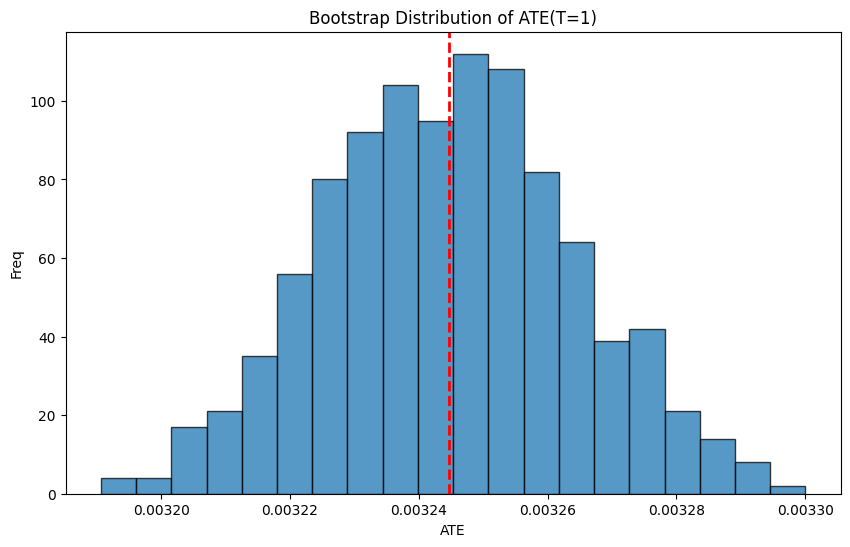

In [14]:
# efeito individual
te_full = dr.effect(X, T0=0, T1=1)
n = len(te_full)

n_boot = 1000
ates = np.zeros(n_boot)
for i in range(n_boot):
    idx = np.random.randint(0, n, n)
    ates[i] = te_full[idx].mean()

low, high = np.percentile(ates, [2.5, 97.5])
print(f"ATE mean: {ates.mean():.6f}")
print(f"95% CI: [{low:.6f}, {high:.6f}]")

plt.figure(figsize=(10,6))
plt.hist(ates, bins=20, edgecolor='black', alpha=0.75)
plt.axvline(ates.mean(), color='red', linestyle='dashed', linewidth=2)
plt.title("Bootstrap Distribution of ATE(T=1)")
plt.xlabel("ATE")
plt.ylabel("Freq")
plt.show()

# Estimating uncertainty around the causal effect using non-parametric bootstrapping.
#
# 1. Compute the individual treatment effects (CATE) for the comparison T1=1 vs T0=0.
# 2. Generate 'n_boot' bootstrap samples by resampling the CATEs with replacement.
#    For each resample, compute the mean effect (ATE).
# 3. The resulting distribution of ATEs allows us to estimate a 95% confidence interval
#    without relying on parametric assumptions.

ATE mean: 0.006800
95% CI: [0.006770, 0.006830]


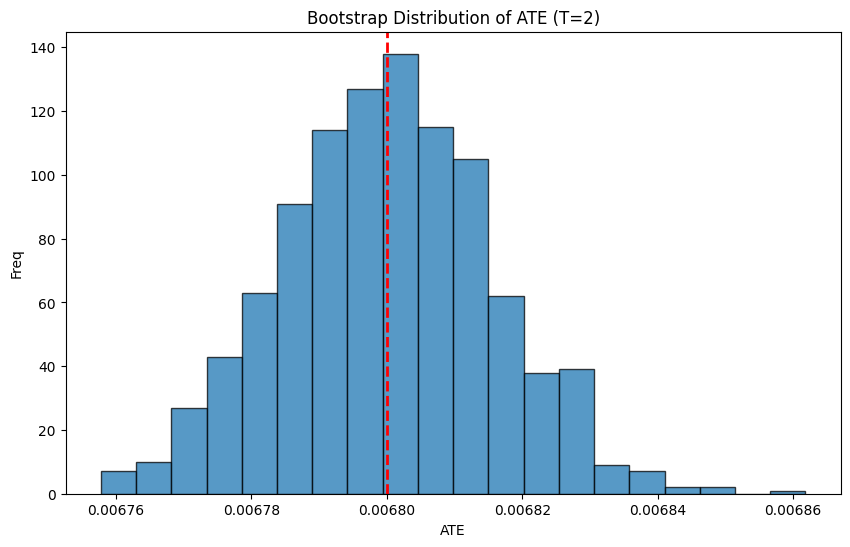

In [15]:
te_full = dr.effect(X, T0=0, T1=2)
n = len(te_full)

n_boot = 1000
ates = np.zeros(n_boot)

for i in range(n_boot):
    idx = np.random.randint(0, n, n)
    ates[i] = te_full[idx].mean()

low, high = np.percentile(ates, [2.5, 97.5])
print(f"ATE mean: {ates.mean():.6f}")
print(f"95% CI: [{low:.6f}, {high:.6f}]")

plt.figure(figsize=(10,6))
plt.hist(ates, bins=20, edgecolor='black', alpha=0.75)
plt.axvline(ates.mean(), color='red', linestyle='dashed', linewidth=2)
plt.title("Bootstrap Distribution of ATE (T=2)")
plt.xlabel("ATE")
plt.ylabel("Freq")
plt.show()

# Estimating uncertainty around the causal effect using non-parametric bootstrapping.
#
# 1. Compute the individual treatment effects (CATE) for the comparison T1=1 vs T0=0.
# 2. Generate 'n_boot' bootstrap samples by resampling the CATEs with replacement.
#    For each resample, compute the mean effect (ATE).
# 3. The resulting distribution of ATEs allows us to estimate a 95% confidence interval
#    without relying on parametric assumptions.

In [16]:
Y_placebo = np.random.permutation(Y)

dr.fit(Y_placebo, T, X=X)

ate_placebo = dr.effect(X, T0=0, T1=1).mean()
print("ATE placebo:", ate_placebo)

# Placebo test: verifying whether the model detects a causal effect when no
# true relationship exists.
#
# We randomly permute the outcome variable (Y), breaking any real association
# between treatment, covariates, and the response. If the DRLearner is behaving
# properly, the estimated ATE should be close to zero, since the data now contain
# no genuine causal signal.
#
# A large or significant placebo ATE would indicate that the model is capturing
# spurious structure (overfitting or model-induced artifacts), suggesting that
# the original causal estimates should be interpreted with caution.

ATE placebo: 0.0005231355939906641
